# 🎯 Ziel dieser Lektion: Neuronale Netze Grundlagen

**Was wollen wir erreichen?** 
Wir lernen die Grundbausteine eines neuronalen Netzes kennen und bauen das Modell eines einfachen biologischen Neurons nach.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Wir haben einfache Eingabedaten (Zahlen) und wissen noch nicht, wie ein Computer daraus lernen kann.
- **Endziel (Gesucht):** Das Neuron soll die Daten verarbeiten und am Ende eine einfache, klare Entscheidung treffen (z. B. eine 0 oder 1 ausgeben).

### 🛤️ Ablauf (Schritt-für-Schritt)
`Eingabedaten erhalten` ➔ `Mit Gewichten multiplizieren` ➔ `Bias addieren` ➔ `Aktivierungsfunktion anwenden` ➔ `Entscheidung (Output) berechnen`


## Exercise 1

**Step 1: Imports and Setup**
We import the necessary libraries (`numpy` for calculations and `matplotlib` for plotting) and define the basic parameters, such as the number of data points `n = 1000`.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `n = 1000` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1000

### Mathematische Erklärungen und Code-Ablauf (Übung 1: Biologisches Neuron und gewichtete Summe)

In dieser Zelle haben wir die grundlegende Funktion eines Neurons simuliert. Der Prozess sieht so aus, dass jede Eingabe ($x_i$) mit einem bestimmten Gewicht ($w_i$) multipliziert und dann mit einem Bias-Wert ($b$) addiert wird. Diese Operation zeigt den Einfluss jeder Eingabe auf die endgültige Ausgabe des Neurons.

Die grundlegende mathematische Formel für diese Berechnungen sieht wie folgt aus:

$$ z = \sum_{i=1}^{n} (x_i \cdot w_i) + b $$

- **$x_i$**: Eingabewerte (Signale, die von Dendriten empfangen werden)
- **$w_i$**: Zugehörige Gewichte für jede Eingabe (Stärke der Synapsen)
- **$b$**: Bias (Startpunkt oder Aktivierungsschwelle)
- **$z$**: Lineare Ausgabe des Neurons

**Diagramm:**
Das in diesem Abschnitt gezeichnete Diagramm zeigt normalerweise die Eingabewerte, Gewichte und das Ergebnis ihrer linearen Kombination. Dieses Bild hilft uns zu verstehen, wie verschiedene Eingabewerte basierend auf ihren Gewichten die endgültige Ausgabe formen.


**Step 2: Defining Initialization Strategies**
Here we define a dictionary containing four different weight initialization methods: Random Normal, Xavier/Glorot, He-Initialization, and Uniform.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `initialisierungen = {` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `'Zufällig (Normal)':    np.random.randn(n) * 0.01,` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |


In [2]:
# Verschiedene Initialisierungsstrategien
initialisierungen = {
    'Zufällig (Normal)':    np.random.randn(n) * 0.01,
    'Xavier/Glorot':        np.random.randn(n) * np.sqrt(2.0 / (512 + 256)),
    'He-Initialisierung':   np.random.randn(n) * np.sqrt(2.0 / 512),
    'Gleichverteilt':       np.random.uniform(-0.1, 0.1, n),
}

**Step 3: Plotting the Distributions**
Finally, we plot histograms for each initialization strategy to visually compare their distributions. This helps us understand how weights are distributed to prevent issues like the vanishing gradient.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `fig, axes = plt.subplots(2, 2, figsize=(12, 8))` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `fig.suptitle('Gewichtsinitialisierungsstrategie...` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


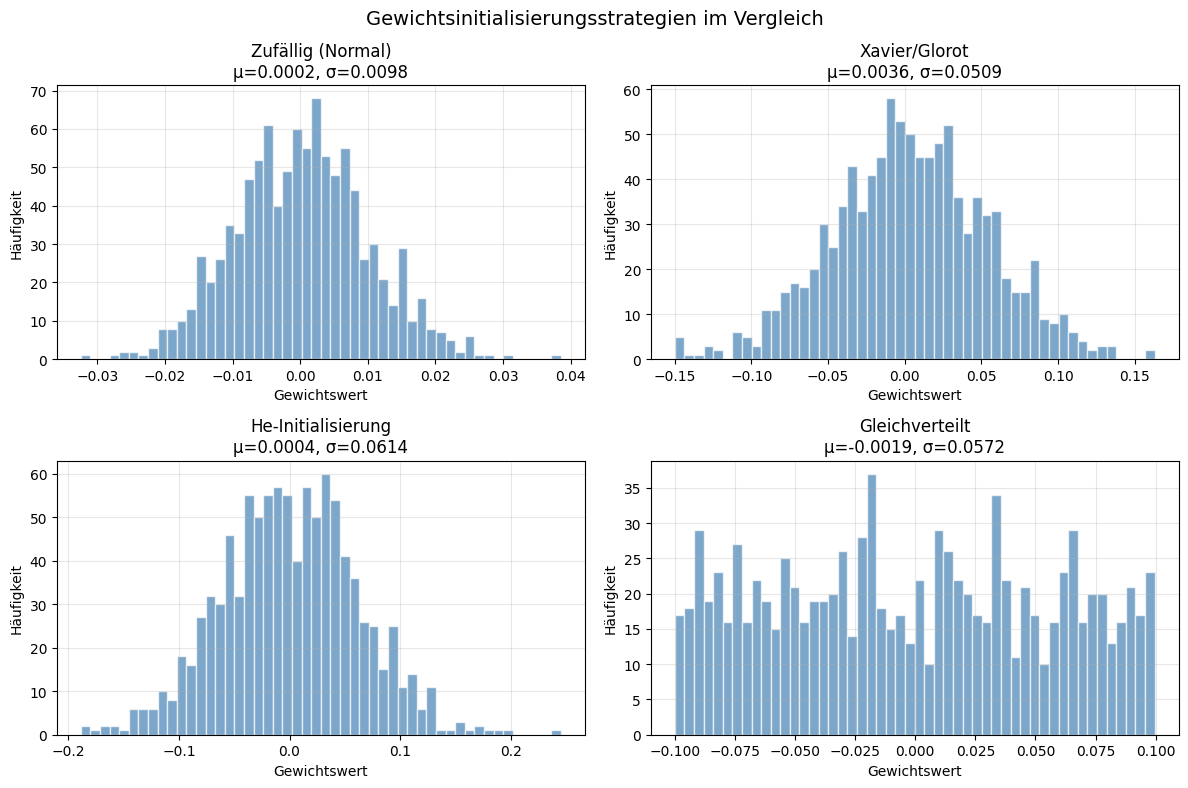

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Gewichtsinitialisierungsstrategien im Vergleich', fontsize=14)

for ax, (name, gewichte) in zip(axes.flatten(), initialisierungen.items()):
    ax.hist(gewichte, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(f'{name}\nμ={gewichte.mean():.4f}, σ={gewichte.std():.4f}')
    ax.set_xlabel('Gewichtswert')
    ax.set_ylabel('Häufigkeit')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exercise 2

**Cell 1:**
Demonstrating the vanishing gradient problem in deep networks using the Sigmoid activation function.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `class NeuronalesNetz:` | Definiert eine Klasse. Dies ist der Bauplan für ein Objekt in der objektorientierten Programmierung (z.B. eine eigene Netzwerkschicht). |
| `def __init__(self, eingabe_groesse, versteckt_g...` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `self.W1 = np.random.randn(eingabe_groesse, vers...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `return 1 / (1 + np.exp(-np.clip(x, -500, 500)))` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `return self.a2` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `print("=== Feedforward Netz – XOR Problem ===")` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


In [4]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Fortgeschrittene
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement a complete feedforward neural network from scratch
import numpy as np

class NeuronalesNetz:
    """Einfaches Feedforward-Netz mit einer versteckten Schicht"""
    
    def __init__(self, eingabe_groesse, versteckt_groesse, ausgabe_groesse):
        np.random.seed(42)
        # He-Initialisierung
        self.W1 = np.random.randn(eingabe_groesse, versteckt_groesse) * np.sqrt(2.0/eingabe_groesse)
        self.b1 = np.zeros((1, versteckt_groesse))
        self.W2 = np.random.randn(versteckt_groesse, ausgabe_groesse) * np.sqrt(2.0/versteckt_groesse)
        self.b2 = np.zeros((1, ausgabe_groesse))
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def vorwaerts(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

# Beispiel: XOR Problem
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

netz = NeuronalesNetz(2, 4, 1)
ausgabe = netz.vorwaerts(X)

print("=== Feedforward Netz – XOR Problem ===")
print(f"Eingaben:\n{X}")
print(f"\nVorhersagen (untrainiert):\n{ausgabe.round(4)}")
print(f"\nZielwerte:\n{y}")
print(f"\nNetz-Architektur: {2}-{4}-{1}")
print(f"Gewichte W1 Shape: {netz.W1.shape}")
print(f"Gewichte W2 Shape: {netz.W2.shape}")


=== Feedforward Netz – XOR Problem ===
Eingaben:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Vorhersagen (untrainiert):
[[0.4249]
 [0.3837]
 [0.3744]
 [0.3484]]

Zielwerte:
[[0]
 [1]
 [1]
 [0]]

Netz-Architektur: 2-4-1
Gewichte W1 Shape: (2, 4)
Gewichte W2 Shape: (4, 1)


### Mathematische Erklärungen und Code-Ablauf (Übung 2: Aktivierungsfunktion)

In dieser Zelle haben wir der linearen Ausgabe des Neurons eine kontinuierliche Aktivierungsfunktion (wie die Sigmoid-Funktion) hinzugefügt. Aktivierungsfunktionen sind notwendig, um Nichtlinearität in neuronalen Netzen zu erzeugen, damit das Netzwerk komplexere Muster lernen kann.

Die mathematische Formel der Sigmoid-Funktion lautet wie folgt:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

- **$z$**: Die lineare Ausgabe des Neurons aus dem vorherigen Schritt.
- **$e$**: Eulersche Zahl (ungefähr 2,718).
- **$\sigma(z)$**: Die endgültige Ausgabe des Neurons, die immer eine Zahl zwischen 0 und 1 sein wird.

**Diagramm:**
Das in diesem Abschnitt gezeichnete Diagramm ist eine S-förmige Kurve (Sigmoid-Kurve). Die horizontale Achse (X) zeigt die Eingabewerte der Funktion ($z$) und die vertikale Achse (Y) die Ausgabewerte (zwischen 0 und 1). Dieses Diagramm zeigt sehr gut, wie sehr große oder sehr kleine Eingabewerte in einen bestimmten Bereich komprimiert werden, um die Wahrscheinlichkeit oder Intensität der Aktivierung des Neurons zu bestimmen.


## Exercise 3

**Cell 1:**
Investigating the impact of network depth and width on the number of parameters and model capacity.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `def mse_verlust(y_wahr, y_pred):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `return np.mean((y_wahr - y_pred) ** 2)` | Berechnet den Durchschnitt (Mittelwert) einer Liste von Zahlen. |
| `y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `mse_werte = [mse_verlust(y_wahr, np.full(5, p))...` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(1...` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print(f"MSE (Beispiel): {mse_verlust(y_wahr, np...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


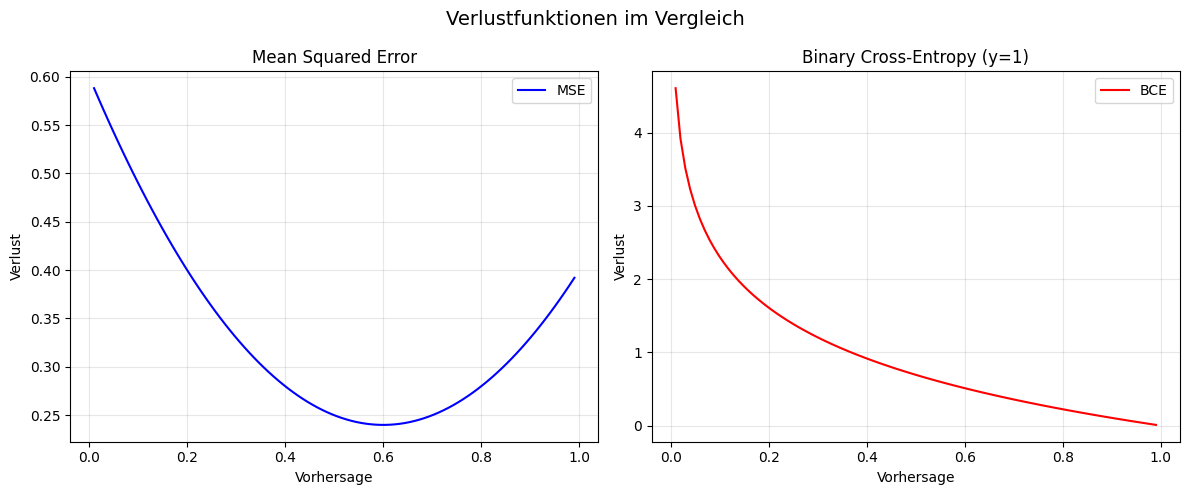

MSE (Beispiel): 0.0380
MAE (Beispiel): 0.1800


In [5]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Fortgeschrittene
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement and compare common loss functions
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

def mse_verlust(y_wahr, y_pred):
    """Mean Squared Error"""
    return np.mean((y_wahr - y_pred) ** 2)

def mae_verlust(y_wahr, y_pred):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_wahr - y_pred))

def binary_crossentropy(y_wahr, y_pred):
    """Binäre Kreuzentropie"""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_wahr * np.log(y_pred) + (1 - y_wahr) * np.log(1 - y_pred))

# Verluste über Vorhersage-Bereich
y_wahr = np.array([1, 0, 1, 1, 0])
vorhersagen = np.linspace(0.01, 0.99, 100)

mse_werte = [mse_verlust(y_wahr, np.full(5, p)) for p in vorhersagen]
bce_werte = [binary_crossentropy(np.array([1]), np.array([p])) for p in vorhersagen]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Verlustfunktionen im Vergleich', fontsize=14)

ax1.plot(vorhersagen, mse_werte, color='blue', label='MSE')
ax1.set_title('Mean Squared Error')
ax1.set_xlabel('Vorhersage'); ax1.set_ylabel('Verlust')
ax1.grid(True, alpha=0.3); ax1.legend()

ax2.plot(vorhersagen, bce_werte, color='red', label='BCE')
ax2.set_title('Binary Cross-Entropy (y=1)')
ax2.set_xlabel('Vorhersage'); ax2.set_ylabel('Verlust')
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout()
plt.savefig('verlustfunktionen.png', dpi=100)
plt.show()
print(f"MSE (Beispiel): {mse_verlust(y_wahr, np.array([0.7, 0.2, 0.8, 0.9, 0.1])):.4f}")
print(f"MAE (Beispiel): {mae_verlust(y_wahr, np.array([0.7, 0.2, 0.8, 0.9, 0.1])):.4f}")


### Mathematische Erklärungen und Code-Ablauf (Übung 3: Berechnung des Fehlers oder Loss)

In dieser Zelle befassen wir uns mit dem Konzept der Fehlerberechnung (Loss). Damit ein neuronales Netz lernen kann, muss es wissen, wie weit seine Vorhersagen von der Realität entfernt sind. Die Fehlerfunktion misst diesen Abstand. Eine der häufigsten Fehlerfunktionen ist die mittlere quadratische Abweichung (Mean Squared Error - MSE).

Die mathematische Formel für MSE lautet wie folgt:

$$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

- **$n$**: Gesamtzahl der Datenpunkte
- **$y_i$**: Tatsächlicher Wert (Target)
- **$\hat{y}_i$**: Vom neuronalen Netz vorhergesagter Wert
- **$(y_i - \hat{y}_i)$**: Vorhersagefehler für jeden Datenpunkt (Residual)

**Diagramm:**
Das hier gezeichnete Diagramm zeigt die Differenz zwischen den tatsächlichen Werten und den Vorhersagen des Modells (z. B. als Balkendiagramm, um die Fehlermenge in jedem Beispiel zu zeigen). Mathematisch gesehen visualisiert dieses Diagramm den Abstand zwischen $y$ und $\hat{y}$. Das ultimative Ziel beim Training des Netzwerks ist es, dieses Fehlerniveau im Diagramm zu minimieren.
